# Hotelling's T-squared Distribution

`Hotelling(dim, df)` is the multivariate generalization of the squared t-statistic. When you test whether the mean vector of `dim` correlated measurements equals a hypothesized value, the T-squared statistic collapses that whole vector into a single number measuring how far the sample mean is from the hypothesis. This distribution is what that number follows when the hypothesis is true.

In [23]:
from symbulate import *

## Draw a value

A single non-negative number -- not a vector.

In [24]:
Hotelling(dim=3, df=10).draw()

3.5305719565332154

## Theoretical mean, variance, and standard deviation

In [25]:
Hotelling(dim=3, df=10).mean(), Hotelling(dim=3, df=10).var(), Hotelling(dim=3, df=10).sd()

(np.float64(5.0), np.float64(37.5), np.float64(6.123724356957945))

## Assign and simulate a random variable

In [26]:
T2 = RV(Hotelling(dim=3, df=10))
T2.sim(10000)

0,9.81867614656304
1,6.088947460970219
2,1.245833563646567
3,1.125336565486558
4,2.316314437382892
5,0.6957782240149857
6,0.6350166185451317
7,8.798742690391983
8,0.6435667510299017
...,...
9999,8.116997238715417


## Plot the pdf

A right-skewed density on the non-negative numbers, like the F-distribution it is built from.

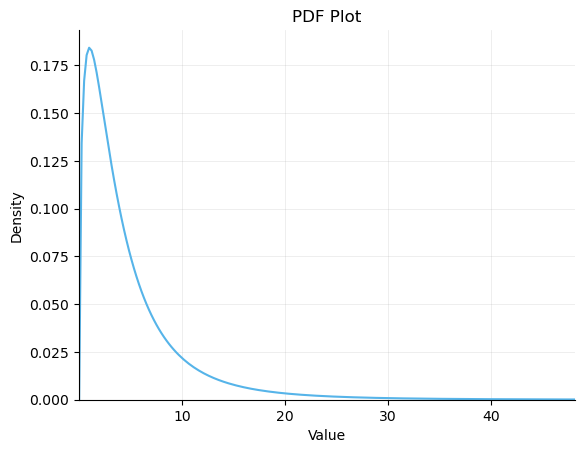

In [27]:
Hotelling(dim=3, df=10).plot()

## Plot the CDF

The CDF is how a T-squared test finds its p-value: the p-value is the tail probability above the observed statistic.

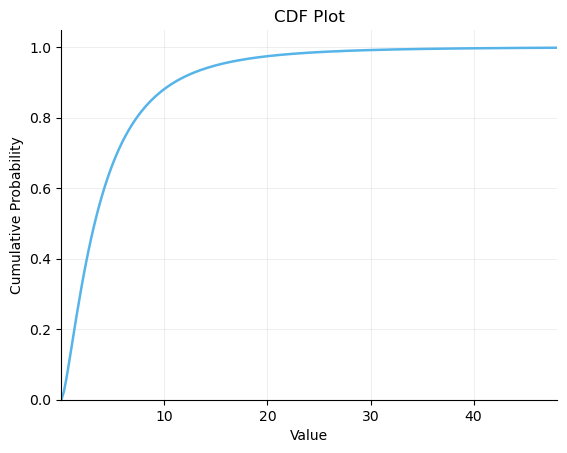

In [28]:
Hotelling(dim=3, df=10).plot(cdf=True)

## More variables shift the distribution to the right

Holding the degrees of freedom fixed, testing more variables at once makes larger T-squared values typical, so the density slides to the right.

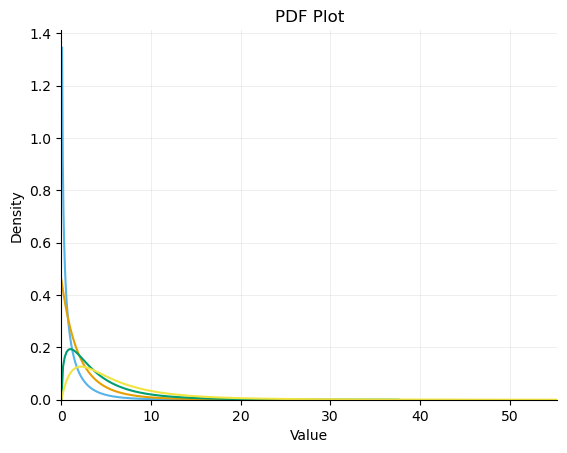

In [29]:
for dim in [1, 2, 3, 4]:
    Hotelling(dim=dim, df=12).plot()

## Relationship: it is a rescaled F-distribution

`Hotelling(dim, df)` equals `(df * dim / (df - dim + 1)) * F(dim, df - dim + 1)`. For `dim=3`, `df=10` the multiplier is `30 / 8 = 3.75`, so scaling an `F(3, 8)` by 3.75 reproduces the Hotelling curve.

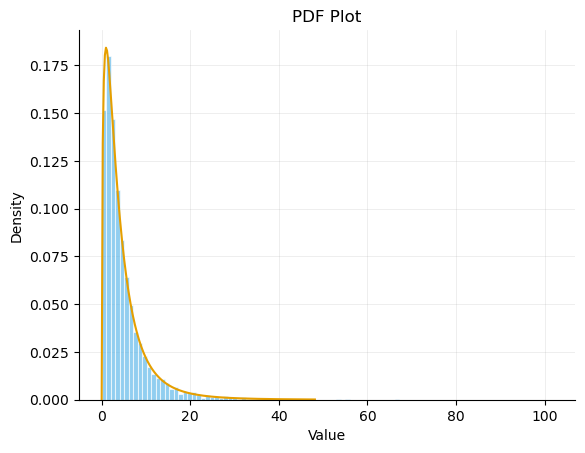

In [30]:
(3.75 * RV(F(dfN=3, dfD=8))).sim(10000).plot(bins=100)
Hotelling(dim=3, df=10).plot()

## Relationship: with one variable it is a squared t

When `dim = 1` the multiplier is 1 and Hotelling's T-squared reduces to `F(1, df)`, which is the square of a `StudentT(df)`. This is the sense in which it generalizes the one-sample squared t-statistic: simulating `StudentT(9) ** 2` matches `Hotelling(dim=1, df=9)`.

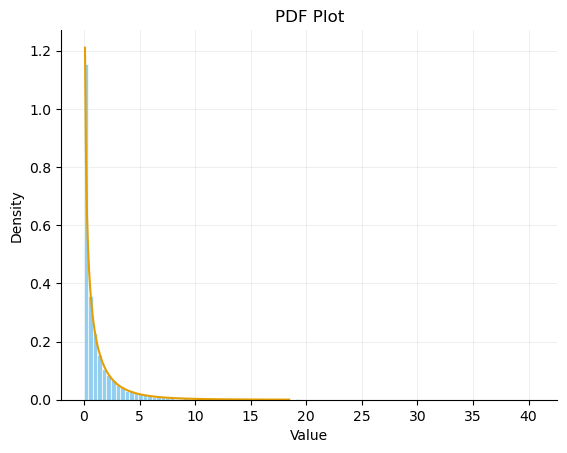

In [31]:
(RV(StudentT(df=9)) ** 2).sim(10000).plot(bins=100)
Hotelling(dim=1, df=9).plot()